# `resti_dataset_3.csv` 변수별 상관계수 시각화

`Data/Restitutor/resti_dataset_3.csv`의 수치형 변수를 기준으로 상관계수를 계산하고 시각화합니다.

1. 데이터 로딩과 결측 현황 확인
2. 전체 상관행렬 히트맵
3. `총 대여수` 기준 상관계수 막대그래프
4. 상관계수가 큰 변수 쌍 요약
5. `|상관계수| >= 0.9` 리스트와 파생변수 삭제 후보
6. 1차 삭제 후 one-hot encoding 제외 재상관분석
7. 축별 대표 변수 성능 비교
8. 축별 최적 조합 적용 및 불필요 컬럼 삭제
9. Train/Valid/Test 분리와 LGBM 하이퍼파라미터 튜닝
10. 최적 하이퍼파라미터 최종 학습 및 Train/Valid 평가


## 0. 라이브러리 및 실행 환경

노트북 위치와 무관하게 프로젝트 루트를 찾고, 한글 라벨이 깨지지 않도록 Matplotlib 폰트를 설정합니다.


In [10]:
from pathlib import Path
import os
import sys
import warnings

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "Data").exists() and (candidate / "Note").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("`Data`와 `Note` 디렉토리를 포함한 프로젝트 루트를 찾지 못했습니다.")

mpl_dir = PROJECT_ROOT / ".mplconfig"
mpl_dir.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(mpl_dir)
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["axes.unicode_minus"] = False

for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]:
    if any(font_name == font.name for font in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = font_name
        break

DATA_PATH = PROJECT_ROOT / "Data" / "Restitutor" / "resti_dataset_3.csv"
CORR_METHOD = "pearson"
TARGET_COL = "총 대여수"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Python executable: {sys.executable}")
print(f"DATA_PATH exists: {DATA_PATH.exists()}")
print(f"Correlation method: {CORR_METHOD}")


PROJECT_ROOT: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/EP_cycle_stations
Python executable: /usr/local/bin/python3
DATA_PATH exists: True
Correlation method: pearson


## 1. 데이터 로딩

문자형 변수(`station_id`, `timestamp`)는 제외하고, 상관계수 계산에는 수치형 변수만 사용합니다.


In [11]:
raw_df = pd.read_csv(DATA_PATH)
numeric_df = raw_df.select_dtypes(include="number").copy()

print(f"원본 데이터 크기: {raw_df.shape[0]:,}행 x {raw_df.shape[1]:,}열")
print(f"수치형 변수 개수: {numeric_df.shape[1]:,}")
print(f"수치형 변수 목록: {', '.join(numeric_df.columns)}")

display(numeric_df.head())

missing_summary = (
    numeric_df.isna().sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

print("결측치가 있는 수치형 변수")
display(missing_summary.query("missing_count > 0"))


원본 데이터 크기: 26,352행 x 38열
수치형 변수 개수: 36
수치형 변수 목록: month, date, hour, weekday, is_weekday, is_restingday, business_ratio, residential_ratio, transit_ratio, leisure_ratio, commute_index, leisure_index, station_capacity, lag_1hr, lag_2hr, lag_3hr, lag_24hr, lag_168hr, rolling_mean_3hr, rolling_mean_6hr, rolling_mean_24hr, rolling_std_24hr, is_rush_hour, is_night, is_daytime, hour_business, hour_transit, 총 대여수, 온도, 습도, 불쾌지수, 강수량, 적설량, rain_flag, snow_flag, leisure_ratio_sq


,month,date,hour,weekday,is_weekday,is_restingday,business_ratio,residential_ratio,transit_ratio,leisure_ratio,...,hour_transit,총 대여수,온도,습도,불쾌지수,강수량,적설량,rain_flag,snow_flag,leisure_ratio_sq
0,1,1,0,0,0,1,0.0178,0.0160,0.0892,0.0171,...,0.0000,0,-2.7000,92.0000,28.4978,0.0000,0.0000,0,0,0.0003
1,1,1,1,0,0,1,0.0178,0.0160,0.0892,0.0171,...,0.0892,0,-1.2000,87.0000,31.8534,0.0000,0.0000,0,0,0.0003
2,1,1,2,0,0,1,0.0178,0.0160,0.0892,0.0171,...,0.1785,3,-1.2000,88.0000,31.6986,0.0000,0.0000,0,0,0.0003
3,1,1,3,0,0,1,0.0178,0.0160,0.0892,0.0171,...,0.2677,1,-1.1000,88.0000,31.8667,0.0000,0.0000,0,0,0.0003
4,1,1,4,0,0,1,0.0178,0.0160,0.0892,0.0171,...,0.3569,2,-1.0000,87.0000,32.1877,0.0000,0.0000,0,0,0.0003


결측치가 있는 수치형 변수


,missing_count
lag_168hr,1008
lag_24hr,144
lag_3hr,18
rolling_std_24hr,12
lag_2hr,12
lag_1hr,6
rolling_mean_24hr,6
rolling_mean_6hr,6
rolling_mean_3hr,6


## 2. 전체 상관행렬 히트맵

상삼각형은 가려서 중복 정보를 줄이고, 색으로 양의 상관과 음의 상관을 구분합니다.


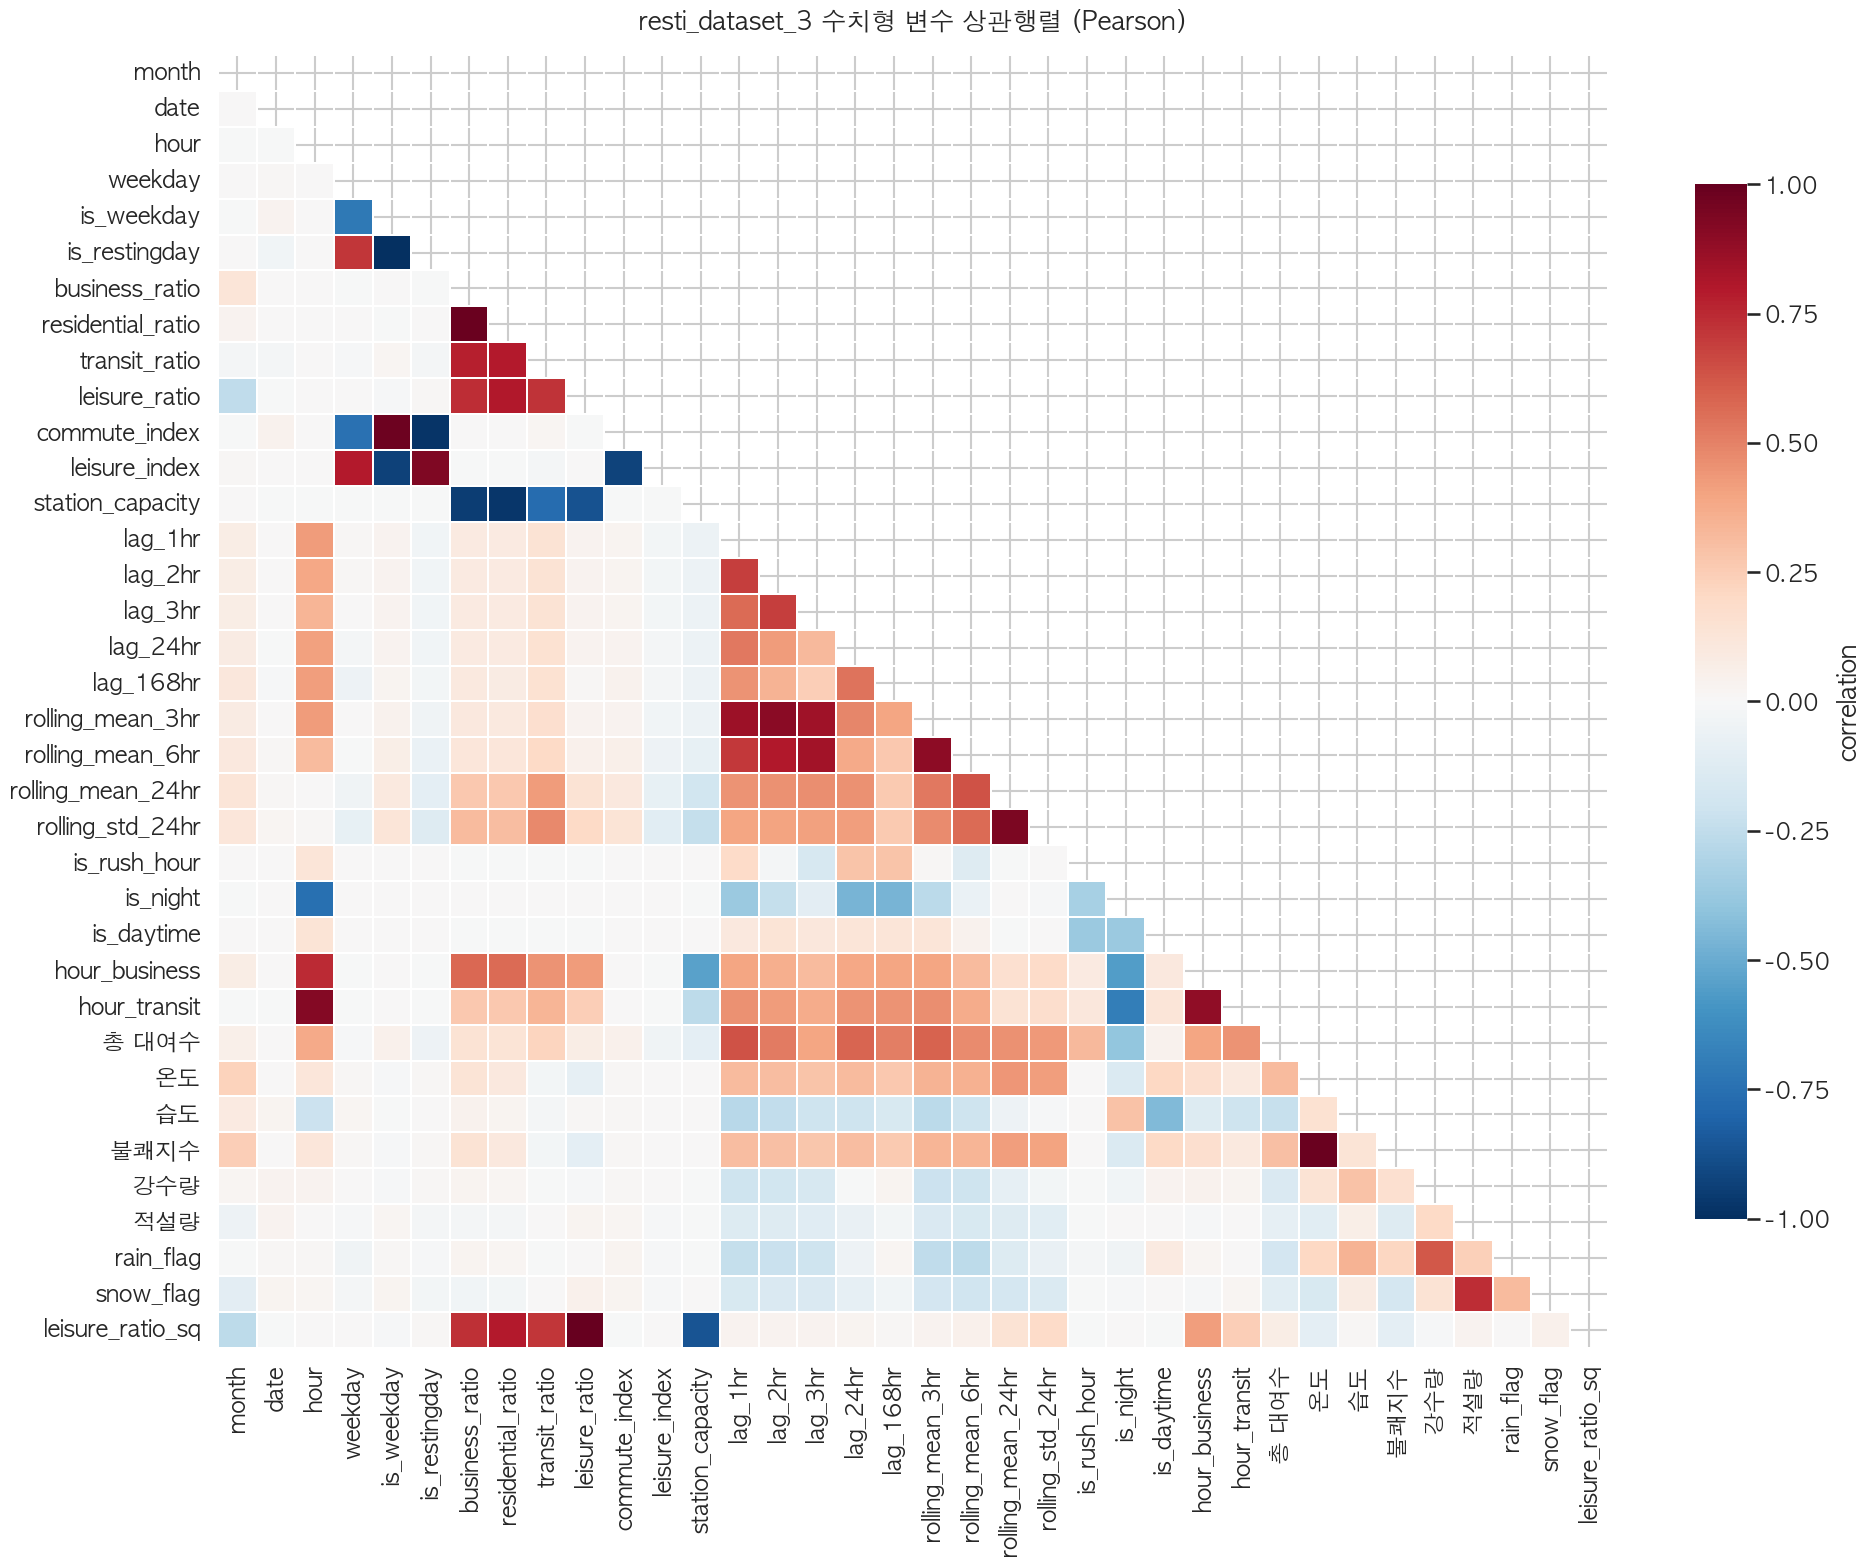

In [12]:
corr_matrix = numeric_df.corr(method=CORR_METHOD)
heatmap_mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    mask=heatmap_mask,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8, "label": "correlation"},
    ax=ax,
)
ax.set_title(f"resti_dataset_3 수치형 변수 상관행렬 ({CORR_METHOD.title()})", pad=18)
plt.tight_layout()
plt.show()


## 3. `총 대여수` 기준 상관계수

수요와 선형적으로 함께 움직이는 변수를 빠르게 확인할 수 있도록 절댓값 기준 상위 변수들을 막대그래프로 확인합니다.


,correlation_with_total_rentals
lag_1hr,0.6404
rolling_mean_3hr,0.5926
lag_24hr,0.5820
lag_2hr,0.5159
lag_168hr,0.5098
rolling_mean_6hr,0.4758
rolling_mean_24hr,0.4594
hour_transit,0.4523
rolling_std_24hr,0.4332
hour_business,0.3983


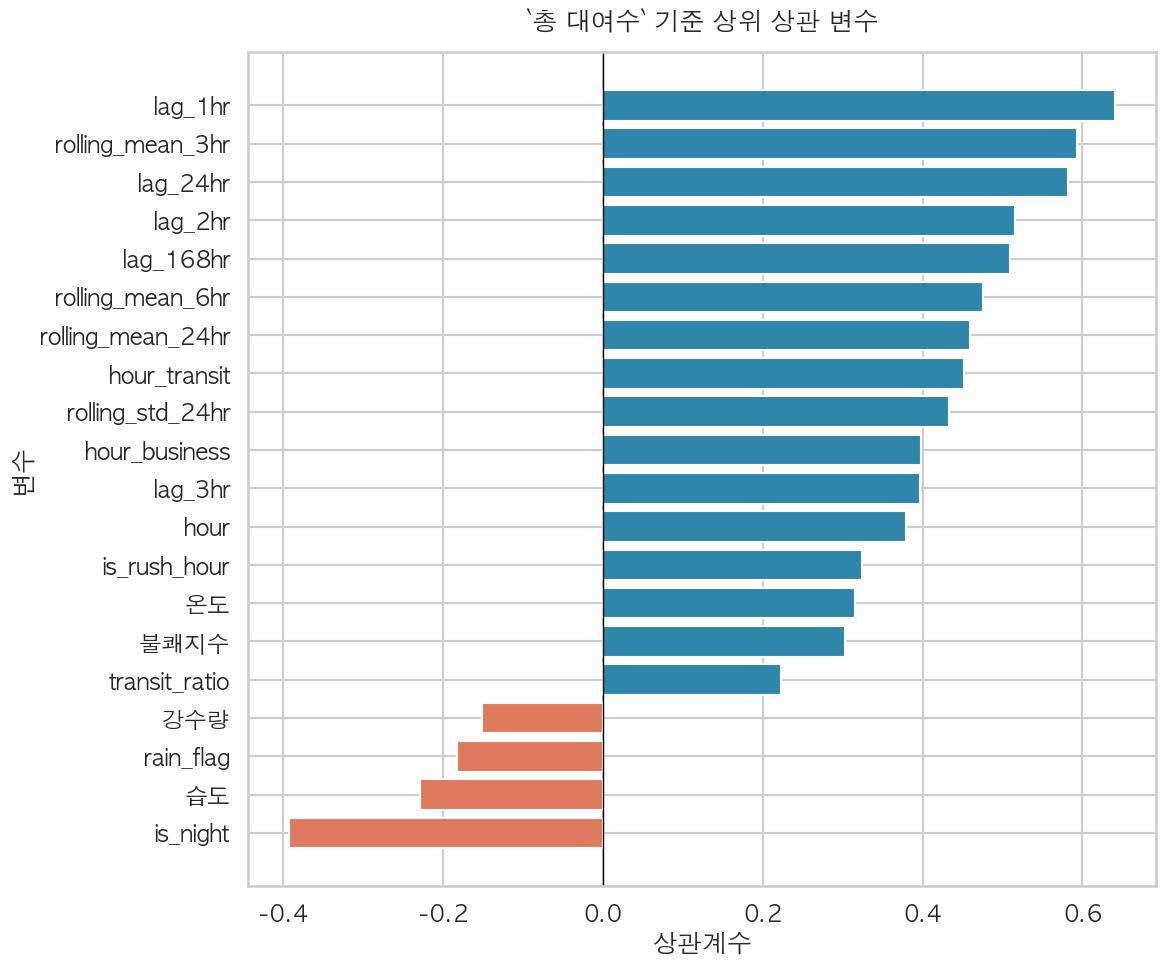

In [13]:
if TARGET_COL not in corr_matrix.columns:
    raise KeyError(f"`{TARGET_COL}` 열이 수치형 변수 목록에 없습니다.")

target_corr = (
    corr_matrix[TARGET_COL]
    .drop(labels=[TARGET_COL])
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

display(target_corr.rename("correlation_with_total_rentals").to_frame().head(20))

plot_data = target_corr.head(20).sort_values()
bar_colors = np.where(plot_data >= 0, "#2E86AB", "#E07A5F")

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(plot_data.index, plot_data.values, color=bar_colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"`{TARGET_COL}` 기준 상위 상관 변수", pad=16)
ax.set_xlabel("상관계수")
ax.set_ylabel("변수")
plt.tight_layout()
plt.show()


## 4. 상관계수가 큰 변수 쌍

자기 자신과의 상관은 제외하고, 절댓값 기준으로 강한 상관을 보이는 변수 쌍을 확인합니다.


,variable_1,variable_2,correlation,abs_correlation
0,is_weekday,is_restingday,-1.0000,1.0000
1,leisure_ratio,leisure_ratio_sq,0.9996,0.9996
2,온도,불쾌지수,0.9916,0.9916
3,business_ratio,residential_ratio,0.9874,0.9874
4,is_weekday,commute_index,0.9841,0.9841
5,is_restingday,commute_index,-0.9841,0.9841
6,residential_ratio,station_capacity,-0.9708,0.9708
7,business_ratio,station_capacity,-0.9519,0.9519
8,rolling_mean_24hr,rolling_std_24hr,0.9382,0.9382
9,is_weekday,leisure_index,-0.9327,0.9327


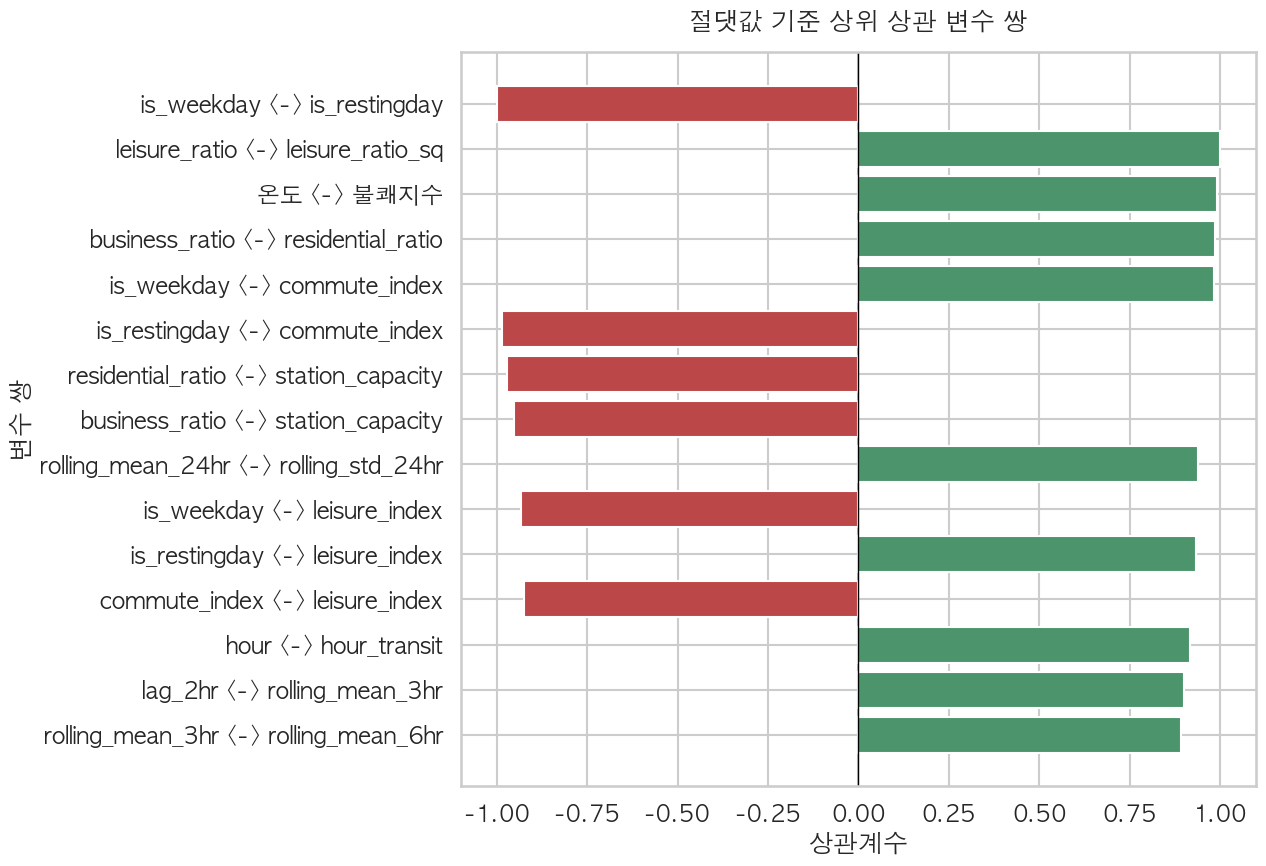

In [14]:
pair_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pair_corr.columns = ["variable_1", "variable_2", "correlation"]
pair_corr["abs_correlation"] = pair_corr["correlation"].abs()

top_pairs = pair_corr.sort_values("abs_correlation", ascending=False).head(15).reset_index(drop=True)
display(top_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))

pair_plot = top_pairs.iloc[::-1].copy()
pair_plot["label"] = pair_plot["variable_1"] + " <-> " + pair_plot["variable_2"]
pair_colors = np.where(pair_plot["correlation"] >= 0, "#4C956C", "#BC4749")

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(pair_plot["label"], pair_plot["correlation"], color=pair_colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("절댓값 기준 상위 상관 변수 쌍", pad=16)
ax.set_xlabel("상관계수")
ax.set_ylabel("변수 쌍")
plt.tight_layout()
plt.show()


## 5. `|상관계수| >= 0.9` 리스트와 파생변수 삭제 후보

상관계수 절댓값이 0.9 이상인 변수 쌍 전체를 출력하고, 파생변수 관계가 명시된 경우에는 기본 변수를 삭제 후보로 표시합니다.


In [15]:
HIGH_CORR_THRESHOLD = 0.9

# 파생변수 -> 기본변수 매핑. 파생변수를 유지할 때 기본변수를 삭제 후보로 둡니다.
DERIVED_FEATURE_RULES = {
    "is_restingday": {"is_weekday"},
    "leisure_ratio_sq": {"leisure_ratio"},
    "불쾌지수": {"온도", "습도"},
    "hour_business": {"hour", "business_ratio"},
    "hour_transit": {"hour", "transit_ratio"},
    "rolling_mean_3hr": {"lag_1hr", "lag_2hr", "lag_3hr"},
}

high_corr_pairs = pair_corr.loc[pair_corr["abs_correlation"] >= HIGH_CORR_THRESHOLD].copy()

def find_drop_candidate(row):
    var1 = row["variable_1"]
    var2 = row["variable_2"]

    for derived_var, base_vars in DERIVED_FEATURE_RULES.items():
        if derived_var == var1 and var2 in base_vars:
            return pd.Series(
                {
                    "derived_variable": derived_var,
                    "base_variable_to_drop": var2,
                    "rule_applied": f"keep `{derived_var}` -> drop `{var2}`",
                }
            )
        if derived_var == var2 and var1 in base_vars:
            return pd.Series(
                {
                    "derived_variable": derived_var,
                    "base_variable_to_drop": var1,
                    "rule_applied": f"keep `{derived_var}` -> drop `{var1}`",
                }
            )

    return pd.Series(
        {
            "derived_variable": pd.NA,
            "base_variable_to_drop": pd.NA,
            "rule_applied": "manual_review",
        }
    )

high_corr_pairs = pd.concat([high_corr_pairs, high_corr_pairs.apply(find_drop_candidate, axis=1)], axis=1)
high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

display(
    high_corr_pairs.style.format(
        {"correlation": "{:.4f}", "abs_correlation": "{:.4f}"},
        na_rep="-",
    )
)

drop_candidates = sorted(high_corr_pairs["base_variable_to_drop"].dropna().unique().tolist())
manual_review_pairs = high_corr_pairs.loc[
    high_corr_pairs["rule_applied"] == "manual_review",
    ["variable_1", "variable_2", "correlation", "abs_correlation"],
]

print(f"상관계수 절댓값 {HIGH_CORR_THRESHOLD} 이상 변수쌍: {len(high_corr_pairs)}개")
print(f"자동 선택된 기본변수 삭제 후보: {drop_candidates}")
print(f"수동 검토 필요 변수쌍: {len(manual_review_pairs)}개")

display(pd.DataFrame({"drop_candidate": drop_candidates}))
display(manual_review_pairs)

numeric_df_pruned = numeric_df.drop(columns=drop_candidates, errors="ignore").copy()
print(f"삭제 전 변수 수: {numeric_df.shape[1]} -> 삭제 후 변수 수: {numeric_df_pruned.shape[1]}")


,variable_1,variable_2,correlation,abs_correlation,derived_variable,base_variable_to_drop,rule_applied
0,is_weekday,is_restingday,-1.0000,1.0000,is_restingday,is_weekday,keep `is_restingday` -> drop `is_weekday`
1,leisure_ratio,leisure_ratio_sq,0.9996,0.9996,leisure_ratio_sq,leisure_ratio,keep `leisure_ratio_sq` -> drop `leisure_ratio`
2,온도,불쾌지수,0.9916,0.9916,불쾌지수,온도,keep `불쾌지수` -> drop `온도`
3,business_ratio,residential_ratio,0.9874,0.9874,-,-,manual_review
4,is_weekday,commute_index,0.9841,0.9841,-,-,manual_review
5,is_restingday,commute_index,-0.9841,0.9841,-,-,manual_review
6,residential_ratio,station_capacity,-0.9708,0.9708,-,-,manual_review
7,business_ratio,station_capacity,-0.9519,0.9519,-,-,manual_review
8,rolling_mean_24hr,rolling_std_24hr,0.9382,0.9382,-,-,manual_review
9,is_weekday,leisure_index,-0.9327,0.9327,-,-,manual_review


상관계수 절댓값 0.9 이상 변수쌍: 14개
자동 선택된 기본변수 삭제 후보: ['hour', 'is_weekday', 'lag_2hr', 'leisure_ratio', '온도']
수동 검토 필요 변수쌍: 9개


,drop_candidate
0,hour
1,is_weekday
2,lag_2hr
3,leisure_ratio
4,온도


,variable_1,variable_2,correlation,abs_correlation
3,business_ratio,residential_ratio,0.9874,0.9874
4,is_weekday,commute_index,0.9841,0.9841
5,is_restingday,commute_index,-0.9841,0.9841
6,residential_ratio,station_capacity,-0.9708,0.9708
7,business_ratio,station_capacity,-0.9519,0.9519
8,rolling_mean_24hr,rolling_std_24hr,0.9382,0.9382
9,is_weekday,leisure_index,-0.9327,0.9327
10,is_restingday,leisure_index,0.9327,0.9327
11,commute_index,leisure_index,-0.9233,0.9233


삭제 전 변수 수: 36 -> 삭제 후 변수 수: 31


In [17]:
drop_cols = ['hour', 'lag_2hr', 'leisure_ratio', '온도']
raw_df.drop(columns=drop_cols, inplace=True)

## 6. 1차 삭제 후 one-hot encoding 제외 재상관분석

현재 `raw_df` 상태를 그대로 사용합니다. 따라서 위에서 `raw_df`에서 1차 삭제를 진행했다면 그 결과를 반영하고, 그중 0/1 binary(one-hot 성격) 변수는 제외한 뒤 다시 상관관계를 계산합니다.


현재 raw_df 기준 수치형 변수 수: 36
제외한 one-hot/binary 변수 수: 7
one-hot/binary 제외 후 변수 수: 29


,excluded_one_hot_column
0,is_weekday
1,is_restingday
2,is_rush_hour
3,is_night
4,is_daytime
5,rain_flag
6,snow_flag


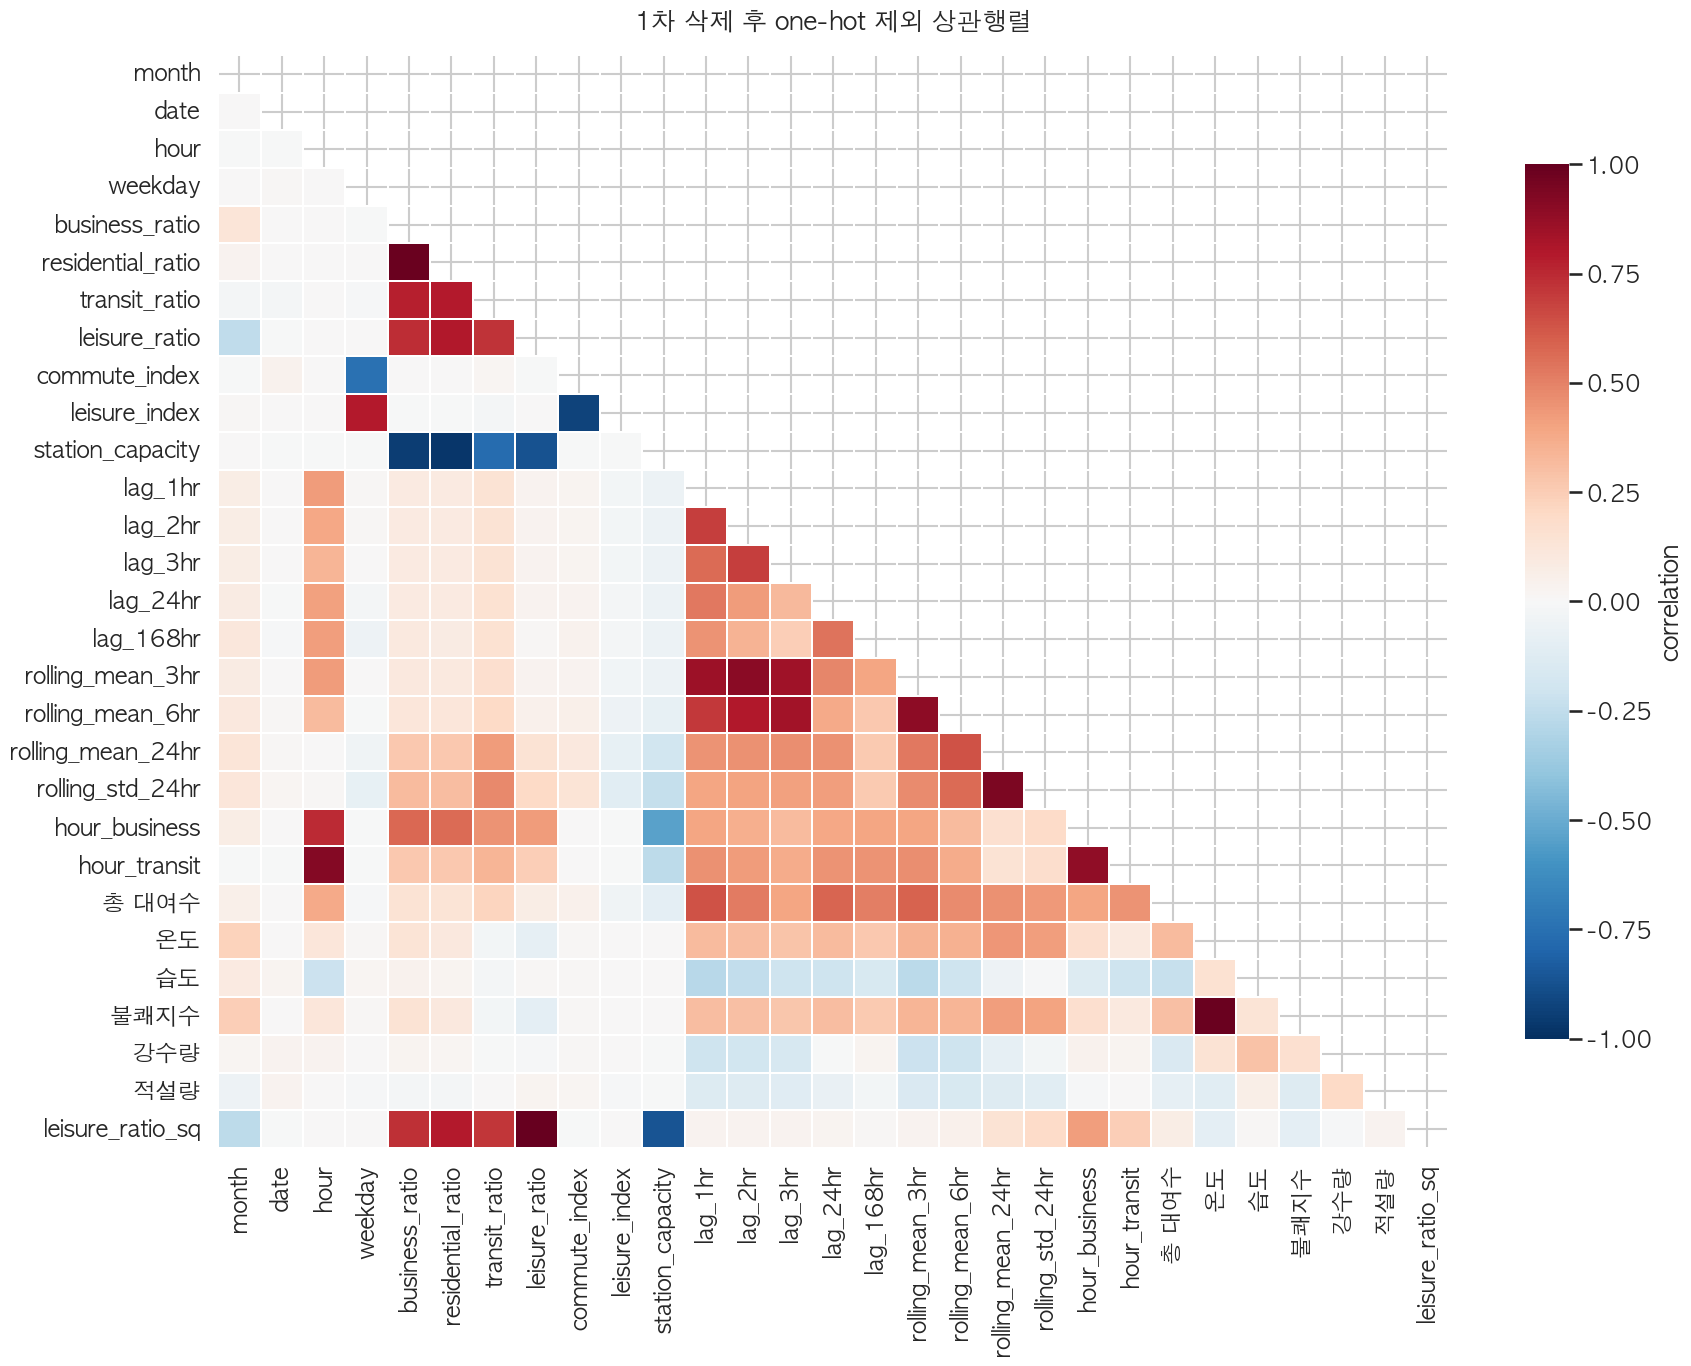

one-hot 제외 후 절댓값 기준 상위 상관 변수 쌍


,variable_1,variable_2,correlation,abs_correlation
0,leisure_ratio,leisure_ratio_sq,0.9996,0.9996
1,온도,불쾌지수,0.9916,0.9916
2,business_ratio,residential_ratio,0.9874,0.9874
3,residential_ratio,station_capacity,-0.9708,0.9708
4,business_ratio,station_capacity,-0.9519,0.9519
5,rolling_mean_24hr,rolling_std_24hr,0.9382,0.9382
6,commute_index,leisure_index,-0.9233,0.9233
7,hour,hour_transit,0.9168,0.9168
8,lag_2hr,rolling_mean_3hr,0.9001,0.9001
9,rolling_mean_3hr,rolling_mean_6hr,0.8935,0.8935


In [16]:
def is_one_hot_like(series):
    values = set(series.dropna().unique().tolist())
    return len(values) <= 2 and values.issubset({0, 1})

raw_df_numeric_current = raw_df.select_dtypes(include="number").copy()
one_hot_excluded_cols = [
    col for col in raw_df_numeric_current.columns
    if is_one_hot_like(raw_df_numeric_current[col])
]

corr_df_no_ohe = raw_df_numeric_current.drop(columns=one_hot_excluded_cols, errors="ignore").copy()

print(f"현재 raw_df 기준 수치형 변수 수: {raw_df_numeric_current.shape[1]}")
print(f"제외한 one-hot/binary 변수 수: {len(one_hot_excluded_cols)}")
print(f"one-hot/binary 제외 후 변수 수: {corr_df_no_ohe.shape[1]}")

display(pd.DataFrame({"excluded_one_hot_column": one_hot_excluded_cols}))

if corr_df_no_ohe.shape[1] < 2:
    raise ValueError("one-hot 제외 후 상관계수를 계산할 수 있는 수치형 변수가 2개 미만입니다.")

corr_matrix_no_ohe = corr_df_no_ohe.corr(method=CORR_METHOD)
heatmap_mask_no_ohe = np.triu(np.ones_like(corr_matrix_no_ohe, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix_no_ohe,
    mask=heatmap_mask_no_ohe,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8, "label": "correlation"},
    ax=ax,
)
ax.set_title("1차 삭제 후 one-hot 제외 상관행렬", pad=18)
plt.tight_layout()
plt.show()

pair_corr_no_ohe = (
    corr_matrix_no_ohe.where(np.triu(np.ones(corr_matrix_no_ohe.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pair_corr_no_ohe.columns = ["variable_1", "variable_2", "correlation"]
pair_corr_no_ohe["abs_correlation"] = pair_corr_no_ohe["correlation"].abs()

top_pairs_no_ohe = pair_corr_no_ohe.sort_values("abs_correlation", ascending=False).head(15).reset_index(drop=True)
print("one-hot 제외 후 절댓값 기준 상위 상관 변수 쌍")
display(top_pairs_no_ohe.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))


## 7. 축별 대표 변수 성능 비교

상관관계로 묶인 축마다 대표 변수 조합을 바꿔가며 `총 대여수` 예측 성능을 비교합니다. 6번 섹션의 one-hot 제외 기준을 그대로 사용하고, 나머지 변수는 고정한 상태에서 축 내부 후보만 교체합니다.


학습 구간 마지막 시점: 2024-10-19 18:00:00
train rows: 21,081, valid rows: 5,271


,axis,axis_title,variant,feature_count,mae,rmse,r2
0,mobility_behavior_axis,통근/여가 축,commute + weekday,23,1.9510,2.6235,0.6681
1,mobility_behavior_axis,통근/여가 축,leisure + weekday,23,1.9664,2.6459,0.6624
2,mobility_behavior_axis,통근/여가 축,weekday,22,1.9594,2.6533,0.6605
3,mobility_behavior_axis,통근/여가 축,commute_index,22,1.9643,2.6550,0.6600
4,mobility_behavior_axis,통근/여가 축,leisure_index,22,1.9932,2.6713,0.6559
5,mobility_behavior_axis,통근/여가 축,none,21,2.0242,2.7257,0.6417
6,recent_demand_axis,최근 수요 축,rolling_mean_3hr,19,1.9868,2.6656,0.6573
7,recent_demand_axis,최근 수요 축,lag_1hr + rolling_mean_3hr,20,1.9804,2.6700,0.6562
8,recent_demand_axis,최근 수요 축,lag_1hr,19,2.0084,2.6964,0.6493
9,recent_demand_axis,최근 수요 축,rolling_mean_6hr,19,2.0288,2.7262,0.6416


축별 최적 조합


,axis,axis_title,variant,feature_count,mae,rmse,r2
0,mobility_behavior_axis,통근/여가 축,commute + weekday,23,1.9510,2.6235,0.6681
1,station_profile_axis,입지/규모 축,residential_ratio,22,1.9572,2.6421,0.6633
2,time_interaction_axis,시간 상호작용 축,hour_transit,23,1.9534,2.6426,0.6632
3,recent_demand_axis,최근 수요 축,rolling_mean_3hr,19,1.9868,2.6656,0.6573


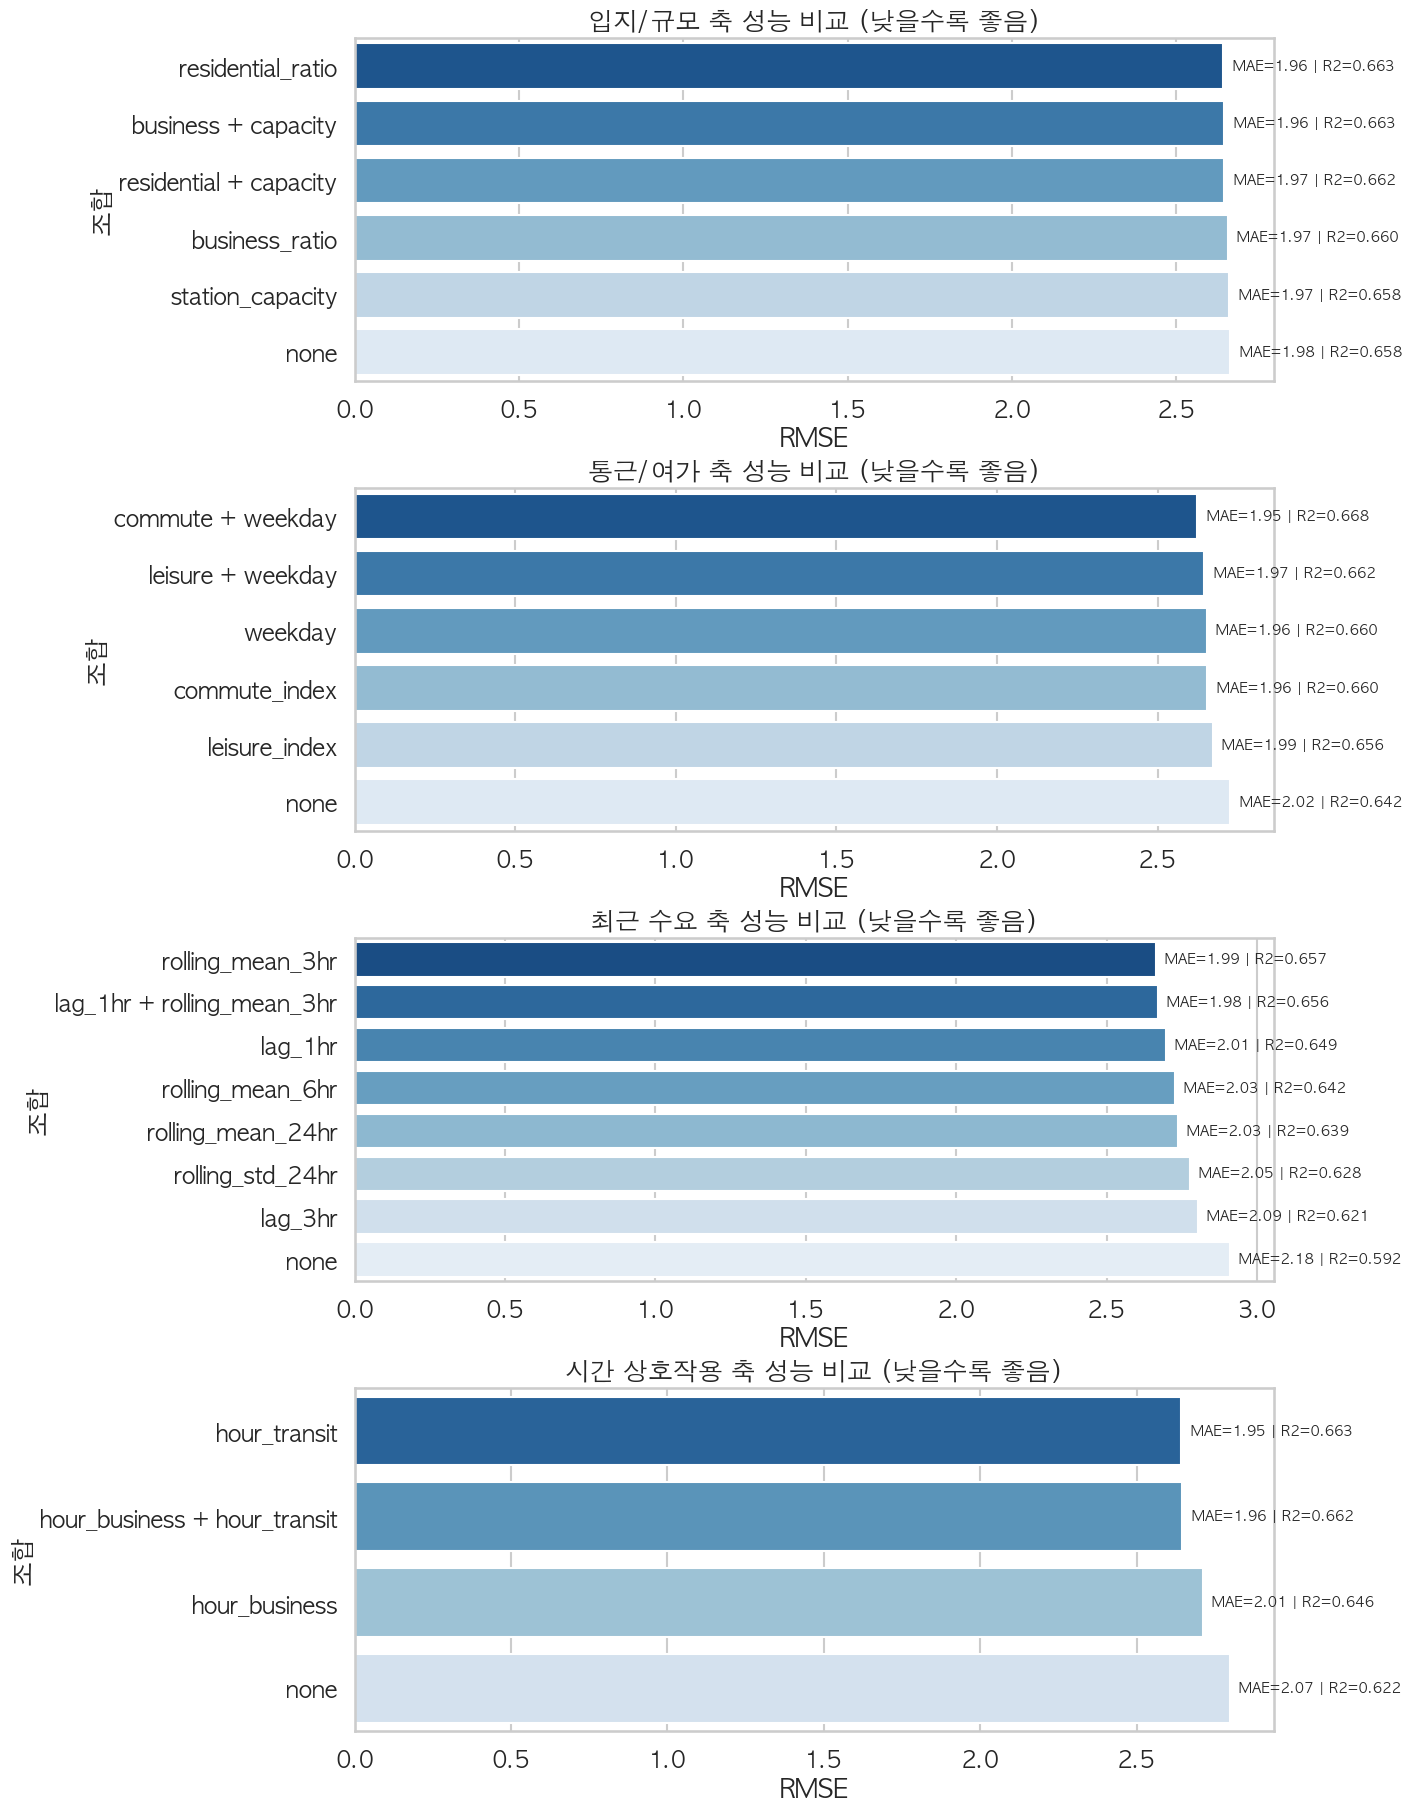

In [20]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_df = raw_df.copy()
model_df["timestamp_dt"] = pd.to_datetime(model_df["timestamp"], errors="coerce")

if model_df["timestamp_dt"].notna().sum() < 2:
    raise ValueError("성능 비교를 위한 `timestamp` 정보가 충분하지 않습니다.")

unique_timestamps = np.array(sorted(model_df["timestamp_dt"].dropna().unique()))
split_index = min(max(1, int(len(unique_timestamps) * 0.8)), len(unique_timestamps) - 1)
split_timestamp = unique_timestamps[split_index - 1]

train_mask = model_df["timestamp_dt"] <= split_timestamp
valid_mask = model_df["timestamp_dt"] > split_timestamp

available_model_features = [col for col in corr_df_no_ohe.columns if col != TARGET_COL]

AXIS_VARIANTS = {
    "station_profile_axis": {
        "none": [],
        "business_ratio": ["business_ratio"],
        "residential_ratio": ["residential_ratio"],
        "station_capacity": ["station_capacity"],
        "business + capacity": ["business_ratio", "station_capacity"],
        "residential + capacity": ["residential_ratio", "station_capacity"],
    },
    "mobility_behavior_axis": {
        "none": [],
        "commute_index": ["commute_index"],
        "leisure_index": ["leisure_index"],
        "weekday": ["weekday"],
        "commute + weekday": ["commute_index", "weekday"],
        "leisure + weekday": ["leisure_index", "weekday"],
    },
    "recent_demand_axis": {
        "none": [],
        "lag_1hr": ["lag_1hr"],
        "lag_3hr": ["lag_3hr"],
        "rolling_mean_3hr": ["rolling_mean_3hr"],
        "rolling_mean_6hr": ["rolling_mean_6hr"],
        "rolling_mean_24hr": ["rolling_mean_24hr"],
        "rolling_std_24hr": ["rolling_std_24hr"],
        "lag_1hr + rolling_mean_3hr": ["lag_1hr", "rolling_mean_3hr"],
    },
    "time_interaction_axis": {
        "none": [],
        "hour_business": ["hour_business"],
        "hour_transit": ["hour_transit"],
        "hour_business + hour_transit": ["hour_business", "hour_transit"],
    },
}

AXIS_TITLES = {
    "station_profile_axis": "입지/규모 축",
    "mobility_behavior_axis": "통근/여가 축",
    "recent_demand_axis": "최근 수요 축",
    "time_interaction_axis": "시간 상호작용 축",
}

def evaluate_feature_set(feature_cols):
    train_data = model_df.loc[train_mask, feature_cols + [TARGET_COL]].copy()
    valid_data = model_df.loc[valid_mask, feature_cols + [TARGET_COL]].copy()

    X_train = train_data[feature_cols]
    y_train = train_data[TARGET_COL]
    X_valid = valid_data[feature_cols]
    y_valid = valid_data[TARGET_COL]

    model = LGBMRegressor(
        objective="regression",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)

    return {
        "mae": mean_absolute_error(y_valid, predictions),
        "rmse": np.sqrt(mean_squared_error(y_valid, predictions)),
        "r2": r2_score(y_valid, predictions),
    }

axis_results = []
available_feature_set = set(available_model_features)

for axis_name, variants in AXIS_VARIANTS.items():
    axis_candidate_cols = sorted({feature for feature_list in variants.values() for feature in feature_list})
    base_features = [col for col in available_model_features if col not in axis_candidate_cols]

    for variant_name, variant_features in variants.items():
        if not set(variant_features).issubset(available_feature_set):
            continue

        metrics = evaluate_feature_set(base_features + variant_features)
        axis_results.append(
            {
                "axis": axis_name,
                "axis_title": AXIS_TITLES[axis_name],
                "variant": variant_name,
                "feature_count": len(base_features + variant_features),
                **metrics,
            }
        )

axis_results_df = pd.DataFrame(axis_results)
axis_results_df = axis_results_df.sort_values(["axis", "rmse", "mae"]).reset_index(drop=True)

print(f"학습 구간 마지막 시점: {pd.Timestamp(split_timestamp)}")
print(f"train rows: {int(train_mask.sum()):,}, valid rows: {int(valid_mask.sum()):,}")
display(axis_results_df)

best_axis_results = (
    axis_results_df.loc[axis_results_df.groupby("axis")["rmse"].idxmin()]
    .sort_values("rmse")
    .reset_index(drop=True)
)
print("축별 최적 조합")
display(best_axis_results)

axis_order = [axis for axis in AXIS_TITLES if axis in axis_results_df["axis"].unique()]
fig, axes = plt.subplots(len(axis_order), 1, figsize=(14, 4.5 * len(axis_order)), constrained_layout=True)
if len(axis_order) == 1:
    axes = [axes]

for ax, axis_name in zip(axes, axis_order):
    plot_df = axis_results_df.loc[axis_results_df["axis"] == axis_name].sort_values("rmse").reset_index(drop=True)
    sns.barplot(data=plot_df, x="rmse", y="variant", hue="variant", dodge=False, palette="Blues_r", ax=ax, legend=False)
    ax.set_title(f"{AXIS_TITLES[axis_name]} 성능 비교 (낮을수록 좋음)")
    ax.set_xlabel("RMSE")
    ax.set_ylabel("조합")

    offset = max(plot_df["rmse"].std(), 1.0) * 0.03
    for row_index, row in plot_df.iterrows():
        ax.text(row["rmse"] + offset, row_index, f"MAE={row['mae']:.2f} | R2={row['r2']:.3f}", va="center", fontsize=10)

plt.show()


## 8. 축별 최적 조합 적용 및 불필요 컬럼 삭제

7번 섹션의 최적 조합 결과를 바탕으로 축 내부 후보들 중 유지할 컬럼과 삭제할 컬럼을 자동으로 계산합니다. 삭제 적용 결과는 `raw_df_axis_selected`로 따로 저장합니다.


In [21]:
axis_selection_summary = []
selected_axis_features = set()
candidate_axis_features = set()

for axis_name, variants in AXIS_VARIANTS.items():
    available_axis_features = {
        feature
        for feature_list in variants.values()
        for feature in feature_list
        if feature in raw_df.columns
    }
    candidate_axis_features.update(available_axis_features)

    best_row = best_axis_results.loc[best_axis_results["axis"] == axis_name]
    if best_row.empty:
        continue

    best_variant = best_row.iloc[0]["variant"]
    keep_features = [feature for feature in AXIS_VARIANTS[axis_name][best_variant] if feature in raw_df.columns]
    selected_axis_features.update(keep_features)

    axis_selection_summary.append(
        {
            "axis_title": AXIS_TITLES[axis_name],
            "selected_variant": best_variant,
            "keep_features": ", ".join(keep_features) if keep_features else "(drop all axis features)",
        }
    )

optimal_drop_cols = sorted(candidate_axis_features - selected_axis_features)

print("축별 최종 유지 조합")
display(pd.DataFrame(axis_selection_summary))

print(f"축 후보 전체 컬럼 수: {len(candidate_axis_features)}")
print(f"축 기준 최종 유지 컬럼 수: {len(selected_axis_features)}")
print(f"삭제 대상 컬럼 수: {len(optimal_drop_cols)}")
display(pd.DataFrame({"optimal_drop_column": optimal_drop_cols}))

raw_df_axis_selected = raw_df.drop(columns=optimal_drop_cols, errors="ignore").copy()
numeric_axis_selected = raw_df_axis_selected.select_dtypes(include="number").copy()
one_hot_excluded_after_axis = [
    col for col in numeric_axis_selected.columns
    if is_one_hot_like(numeric_axis_selected[col])
]
model_df_axis_selected = numeric_axis_selected.drop(columns=one_hot_excluded_after_axis, errors="ignore").copy()

print(f"삭제 적용 후 raw_df_axis_selected shape: {raw_df_axis_selected.shape}")
print(f"one-hot 제외 후 최종 모델링 변수 수(타깃 포함): {model_df_axis_selected.shape[1]}")

# 필요하면 아래 한 줄로 raw_df 자체를 갱신해서 이후 셀에 바로 반영할 수 있습니다.
raw_df = raw_df_axis_selected.copy()


축별 최종 유지 조합


,axis_title,selected_variant,keep_features
0,입지/규모 축,residential_ratio,residential_ratio
1,통근/여가 축,commute + weekday,"commute_index, weekday"
2,최근 수요 축,rolling_mean_3hr,rolling_mean_3hr
3,시간 상호작용 축,hour_transit,hour_transit


축 후보 전체 컬럼 수: 14
축 기준 최종 유지 컬럼 수: 5
삭제 대상 컬럼 수: 9


,optimal_drop_column
0,business_ratio
1,hour_business
2,lag_1hr
3,lag_3hr
4,leisure_index
5,rolling_mean_24hr
6,rolling_mean_6hr
7,rolling_std_24hr
8,station_capacity


삭제 적용 후 raw_df_axis_selected shape: (26352, 25)
one-hot 제외 후 최종 모델링 변수 수(타깃 포함): 16


In [23]:
raw_df.columns

Index(['station_id', 'month', 'date', 'weekday', 'is_weekday', 'is_restingday',
       'residential_ratio', 'transit_ratio', 'commute_index', 'lag_24hr',
       'lag_168hr', 'rolling_mean_3hr', 'is_rush_hour', 'is_night',
       'is_daytime', 'hour_transit', '총 대여수', 'timestamp', '습도', '불쾌지수', '강수량',
       '적설량', 'rain_flag', 'snow_flag', 'leisure_ratio_sq'],
      dtype='str')

## 9. Train/Valid/Test 분리와 LGBM 하이퍼파라미터 튜닝

현재 `raw_df` 상태를 그대로 사용합니다. 공선성은 앞 단계에서 정리된 컬럼 상태를 따르고, 시계열 누수를 막기 위해 `timestamp` 기준 시간순으로 `train / valid / test`를 분리합니다. `test`는 홀드아웃으로 보존하고, 튜닝은 `train`으로 학습해 `valid`로 비교합니다.


In [24]:
import lightgbm as lgb
import optuna
from sklearn.model_selection import ParameterGrid, ParameterSampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

LGBM_TIME_COL = "timestamp"
LGBM_TARGET_COL = TARGET_COL
LGBM_SEED = 42
LGBM_N_ESTIMATORS = 600
LGBM_EARLY_STOPPING_ROUNDS = 50
TRAIN_RATIO = 0.7
VALID_RATIO = 0.15
TEST_RATIO = 0.15
NUM_RANDOM_TRIALS = 6
NUM_OPTUNA_TRIALS = 6

lgbm_df = raw_df.copy()
lgbm_df["timestamp_dt"] = pd.to_datetime(lgbm_df[LGBM_TIME_COL], errors="coerce")

if lgbm_df["timestamp_dt"].isna().any():
    raise ValueError("`timestamp`를 datetime으로 변환하지 못한 행이 있습니다.")

unique_timestamps = np.array(sorted(lgbm_df["timestamp_dt"].unique()))
if len(unique_timestamps) < 3:
    raise ValueError("Train/Valid/Test 분리를 하기 위한 고유 시점 수가 부족합니다.")

train_end_idx = max(1, int(len(unique_timestamps) * TRAIN_RATIO))
valid_end_idx = max(train_end_idx + 1, int(len(unique_timestamps) * (TRAIN_RATIO + VALID_RATIO)))
valid_end_idx = min(valid_end_idx, len(unique_timestamps) - 1)

train_end_ts = unique_timestamps[train_end_idx - 1]
valid_end_ts = unique_timestamps[valid_end_idx - 1]

train_df_lgbm = lgbm_df.loc[lgbm_df["timestamp_dt"] <= train_end_ts].copy()
valid_df_lgbm = lgbm_df.loc[(lgbm_df["timestamp_dt"] > train_end_ts) & (lgbm_df["timestamp_dt"] <= valid_end_ts)].copy()
test_df_lgbm = lgbm_df.loc[lgbm_df["timestamp_dt"] > valid_end_ts].copy()

feature_cols_lgbm = [
    col for col in raw_df.columns
    if col not in {LGBM_TARGET_COL, LGBM_TIME_COL}
    and (pd.api.types.is_numeric_dtype(raw_df[col]) or col == "station_id")
]
categorical_cols_lgbm = [col for col in ["station_id"] if col in feature_cols_lgbm]
station_categories_lgbm = sorted(lgbm_df["station_id"].astype(str).unique()) if "station_id" in categorical_cols_lgbm else []

def prepare_lgbm_xy(frame, feature_cols):
    X = frame[feature_cols].copy()
    if "station_id" in categorical_cols_lgbm and "station_id" in X.columns:
        X["station_id"] = pd.Categorical(X["station_id"].astype(str), categories=station_categories_lgbm)
    y = frame[LGBM_TARGET_COL].copy()
    return X, y

X_train_lgbm, y_train_lgbm = prepare_lgbm_xy(train_df_lgbm, feature_cols_lgbm)
X_valid_lgbm, y_valid_lgbm = prepare_lgbm_xy(valid_df_lgbm, feature_cols_lgbm)
X_test_lgbm, y_test_lgbm = prepare_lgbm_xy(test_df_lgbm, feature_cols_lgbm)

split_summary_lgbm = pd.DataFrame(
    [
        {
            "split": "train",
            "row_count": len(train_df_lgbm),
            "timestamp_count": train_df_lgbm["timestamp_dt"].nunique(),
            "start": train_df_lgbm["timestamp_dt"].min(),
            "end": train_df_lgbm["timestamp_dt"].max(),
            "target_mean": y_train_lgbm.mean(),
            "target_std": y_train_lgbm.std(),
        },
        {
            "split": "valid",
            "row_count": len(valid_df_lgbm),
            "timestamp_count": valid_df_lgbm["timestamp_dt"].nunique(),
            "start": valid_df_lgbm["timestamp_dt"].min(),
            "end": valid_df_lgbm["timestamp_dt"].max(),
            "target_mean": y_valid_lgbm.mean(),
            "target_std": y_valid_lgbm.std(),
        },
        {
            "split": "test",
            "row_count": len(test_df_lgbm),
            "timestamp_count": test_df_lgbm["timestamp_dt"].nunique(),
            "start": test_df_lgbm["timestamp_dt"].min(),
            "end": test_df_lgbm["timestamp_dt"].max(),
            "target_mean": y_test_lgbm.mean(),
            "target_std": y_test_lgbm.std(),
        },
    ]
)
display(split_summary_lgbm)

GRID_SEARCH_SPACE_LGBM = {
    "objective": ["regression", "poisson"],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 63],
    "min_child_samples": [20],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "reg_alpha": [0.0],
    "reg_lambda": [0.0],
}

RANDOM_SEARCH_SPACE_LGBM = {
    "objective": ["regression", "poisson", "tweedie"],
    "learning_rate": [0.02, 0.03, 0.05, 0.07, 0.1],
    "num_leaves": [15, 31, 47, 63, 95, 127],
    "max_depth": [-1, 8, 12],
    "min_child_samples": [5, 10, 20, 40, 60],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 0.5, 1.0, 2.0],
    "min_split_gain": [0.0, 0.05, 0.1],
    "tweedie_variance_power": [1.1, 1.3, 1.5],
}

def compute_regression_metrics(y_true, y_pred, prefix):
    return {
        f"{prefix}_rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        f"{prefix}_mae": mean_absolute_error(y_true, y_pred),
        f"{prefix}_r2": r2_score(y_true, y_pred),
    }

def clean_lgbm_params(params):
    cleaned = dict(params)
    if cleaned.get("objective") != "tweedie":
        cleaned.pop("tweedie_variance_power", None)
    return cleaned

def build_lgbm_model(params):
    return LGBMRegressor(
        **clean_lgbm_params(params),
        n_estimators=LGBM_N_ESTIMATORS,
        random_state=LGBM_SEED,
        n_jobs=-1,
        force_col_wise=True,
        verbosity=-1,
    )

def fit_and_evaluate_lgbm(params, label):
    model = build_lgbm_model(params)
    model.fit(
        X_train_lgbm,
        y_train_lgbm,
        eval_set=[(X_valid_lgbm, y_valid_lgbm)],
        eval_metric="rmse",
        categorical_feature=categorical_cols_lgbm,
        callbacks=[
            lgb.early_stopping(LGBM_EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(0),
        ],
    )
    best_iteration = model.best_iteration_ or LGBM_N_ESTIMATORS
    train_pred = np.clip(model.predict(X_train_lgbm, num_iteration=best_iteration), 0, None)
    valid_pred = np.clip(model.predict(X_valid_lgbm, num_iteration=best_iteration), 0, None)

    metrics = {
        **compute_regression_metrics(y_train_lgbm, train_pred, prefix="train"),
        **compute_regression_metrics(y_valid_lgbm, valid_pred, prefix="valid"),
        "best_iteration": best_iteration,
        "score": np.sqrt(mean_squared_error(y_valid_lgbm, valid_pred)),
    }
    return {
        "label": label,
        "params": clean_lgbm_params(params),
        "metrics": metrics,
        "model": model,
    }

def result_row_from_run(run, method, trial_id):
    return {
        "method": method,
        "trial_id": trial_id,
        **run["params"],
        **run["metrics"],
    }


,split,row_count,timestamp_count,start,end,target_mean,target_std
0,train,18444,6148,2024-01-01 00:00:00,2024-09-13 03:00:00,5.8390,5.7585
1,valid,3954,1318,2024-09-13 04:00:00,2024-11-07 01:00:00,7.2557,6.2134
2,test,3954,1318,2024-11-07 02:00:00,2024-12-31 23:00:00,4.1813,3.9540


,method,trial_id,colsample_bytree,learning_rate,min_child_samples,num_leaves,objective,reg_alpha,reg_lambda,subsample,train_rmse,train_mae,train_r2,valid_rmse,valid_mae,valid_r2,best_iteration,score
0,grid,2,0.8000,0.0300,20,63,regression,0.0000,0.0000,0.8000,2.3218,1.7254,0.8374,3.3752,2.4621,0.7048,286,3.3752
1,grid,7,0.8000,0.0500,20,63,poisson,0.0000,0.0000,0.8000,2.4228,1.7510,0.8230,3.3798,2.4566,0.7040,330,3.3798
2,grid,3,0.8000,0.0300,20,63,poisson,0.0000,0.0000,0.8000,2.3826,1.7248,0.8288,3.3808,2.4579,0.7039,600,3.3808
3,grid,0,0.8000,0.0300,20,31,regression,0.0000,0.0000,0.8000,2.4698,1.8249,0.8160,3.3844,2.4700,0.7032,440,3.3844
4,grid,6,0.8000,0.0500,20,63,regression,0.0000,0.0000,0.8000,2.3378,1.7396,0.8352,3.3909,2.4698,0.7021,163,3.3909
5,grid,5,0.8000,0.0500,20,31,poisson,0.0000,0.0000,0.8000,2.5905,1.8704,0.7976,3.3929,2.4605,0.7017,421,3.3929
6,grid,1,0.8000,0.0300,20,31,poisson,0.0000,0.0000,0.8000,2.6481,1.9052,0.7885,3.3993,2.4685,0.7006,599,3.3993
7,grid,4,0.8000,0.0500,20,31,regression,0.0000,0.0000,0.8000,2.5985,1.9079,0.7964,3.4037,2.4770,0.6998,174,3.4037


,method,trial_id,subsample,reg_lambda,reg_alpha,objective,num_leaves,min_split_gain,min_child_samples,max_depth,...,colsample_bytree,train_rmse,train_mae,train_r2,valid_rmse,valid_mae,valid_r2,best_iteration,score,tweedie_variance_power
0,random,3,1.0000,0.0000,0.5000,tweedie,95,0.0000,20,-1,...,1.0000,2.4168,1.7096,0.8238,3.3939,2.4556,0.7016,350,3.3939,1.3000
1,random,2,0.7000,0.5000,1.0000,tweedie,127,0.1000,60,-1,...,0.9000,2.2775,1.6392,0.8436,3.4001,2.4681,0.7005,72,3.4001,1.1000
2,random,0,1.0000,0.5000,1.0000,poisson,15,0.0000,60,-1,...,0.9000,2.5535,1.8423,0.8034,3.4032,2.4678,0.6999,589,3.4032,NaN
3,random,5,0.7000,0.5000,0.1000,poisson,127,0.0500,5,12,...,0.7000,2.2529,1.6392,0.8469,3.4050,2.4565,0.6996,579,3.4050,NaN
4,random,4,1.0000,0.5000,0.1000,tweedie,95,0.0000,40,12,...,0.9000,2.5809,1.8120,0.7991,3.4105,2.4699,0.6986,266,3.4105,1.5000
5,random,1,0.8000,0.0000,0.1000,regression,15,0.0000,20,12,...,1.0000,2.4883,1.8289,0.8133,3.4236,2.5005,0.6963,600,3.4236,NaN


,method,trial_id,objective,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,...,min_split_gain,train_rmse,train_mae,train_r2,valid_rmse,valid_mae,valid_r2,best_iteration,score,tweedie_variance_power
0,optuna,4,poisson,0.0870,117,9,56,0.7265,0.7588,0.0678,...,0.0389,2.4161,1.7423,0.8240,3.3840,2.4591,0.7033,175,3.3840,NaN
1,optuna,1,regression,0.0153,50,8,29,0.7874,0.8836,0.2092,...,0.0366,2.4821,1.8155,0.8142,3.3907,2.4727,0.7021,599,3.3907,NaN
2,optuna,3,tweedie,0.0276,29,8,6,0.9728,0.7776,0.9938,...,0.0520,2.5448,1.8100,0.8047,3.4262,2.4693,0.6959,600,3.4262,1.3734
3,optuna,0,poisson,0.0397,33,5,8,0.9599,0.8803,1.0621,...,0.0970,2.6778,1.9198,0.7838,3.4373,2.4838,0.6939,600,3.4373,NaN
4,optuna,5,poisson,0.0191,77,5,49,0.7224,0.9961,1.1584,...,0.0006,2.8992,2.0674,0.7465,3.5135,2.5501,0.6802,600,3.5135,NaN
5,optuna,2,poisson,0.0327,82,4,39,0.7512,0.7195,1.4233,...,0.0808,2.9108,2.0773,0.7445,3.5267,2.5556,0.6777,600,3.5267,NaN


,search_method,train_rmse,train_mae,train_r2,valid_rmse,valid_mae,valid_r2,best_iteration,score,colsample_bytree,learning_rate,min_child_samples,num_leaves,objective,reg_alpha,reg_lambda,subsample,tweedie_variance_power,min_split_gain,max_depth
0,grid,2.3218,1.7254,0.8374,3.3752,2.4621,0.7048,286,3.3752,0.8000,0.0300,20,63,regression,0.0000,0.0000,0.8000,NaN,NaN,NaN
1,optuna,2.4161,1.7423,0.8240,3.3840,2.4591,0.7033,175,3.3840,0.7588,0.0870,56,117,poisson,0.0678,0.8133,0.7265,NaN,0.0389,9.0000
2,random,2.4168,1.7096,0.8238,3.3939,2.4556,0.7016,350,3.3939,1.0000,0.0200,20,95,tweedie,0.5000,0.0000,1.0000,1.3000,0.0000,-1.0000


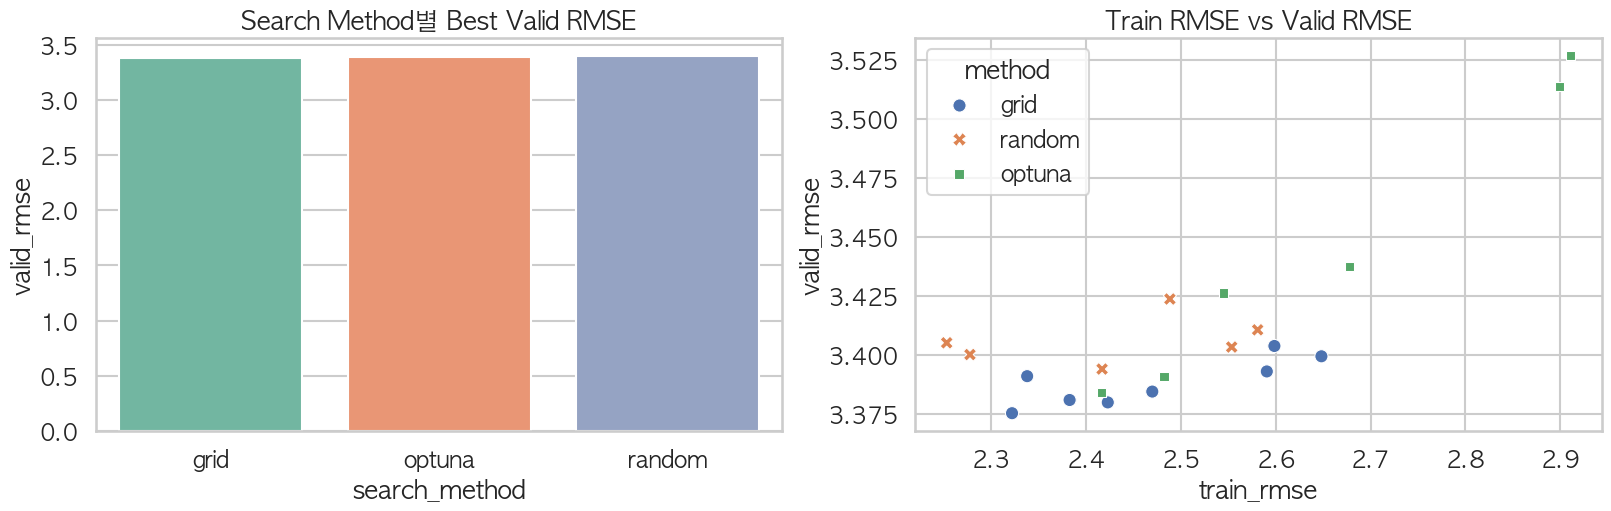

overall_best_method_lgbm: grid


In [25]:
def run_grid_search_lgbm():
    rows = []
    best_run = None
    for trial_idx, params in enumerate(ParameterGrid(GRID_SEARCH_SPACE_LGBM)):
        run = fit_and_evaluate_lgbm(params, label=f"grid_{trial_idx:02d}")
        rows.append(result_row_from_run(run, method="grid", trial_id=trial_idx))
        if best_run is None or run["metrics"]["score"] < best_run["metrics"]["score"]:
            best_run = run
    result_df = pd.DataFrame(rows).sort_values(["score", "valid_mae"]).reset_index(drop=True)
    return best_run, result_df

def run_random_search_lgbm(n_iter=NUM_RANDOM_TRIALS):
    rows = []
    best_run = None
    sampler = ParameterSampler(RANDOM_SEARCH_SPACE_LGBM, n_iter=n_iter, random_state=LGBM_SEED)
    for trial_idx, sampled_params in enumerate(sampler):
        params = clean_lgbm_params(sampled_params)
        run = fit_and_evaluate_lgbm(params, label=f"random_{trial_idx:02d}")
        rows.append(result_row_from_run(run, method="random", trial_id=trial_idx))
        if best_run is None or run["metrics"]["score"] < best_run["metrics"]["score"]:
            best_run = run
    result_df = pd.DataFrame(rows).sort_values(["score", "valid_mae"]).reset_index(drop=True)
    return best_run, result_df

def run_optuna_search_lgbm(n_trials=NUM_OPTUNA_TRIALS):
    sampler = optuna.samplers.TPESampler(seed=LGBM_SEED)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    trial_runs = {}

    def objective(trial):
        objective_name = trial.suggest_categorical("objective", ["regression", "poisson", "tweedie"])
        params = {
            "objective": objective_name,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 16, 128),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.5),
            "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.1),
        }
        if objective_name == "tweedie":
            params["tweedie_variance_power"] = trial.suggest_float("tweedie_variance_power", 1.1, 1.6)

        run = fit_and_evaluate_lgbm(params, label=f"optuna_{trial.number:02d}")
        trial_runs[trial.number] = run
        return run["metrics"]["score"]

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    rows = [result_row_from_run(run, method="optuna", trial_id=trial_id) for trial_id, run in trial_runs.items()]
    result_df = pd.DataFrame(rows).sort_values(["score", "valid_mae"]).reset_index(drop=True)
    best_run = trial_runs[study.best_trial.number]
    return best_run, result_df, study

grid_best_run_lgbm, grid_results_lgbm = run_grid_search_lgbm()
random_best_run_lgbm, random_results_lgbm = run_random_search_lgbm()
optuna_best_run_lgbm, optuna_results_lgbm, optuna_study_lgbm = run_optuna_search_lgbm()

display(grid_results_lgbm)
display(random_results_lgbm)
display(optuna_results_lgbm)

search_best_summary_lgbm = pd.DataFrame(
    [
        {"search_method": "grid", **grid_best_run_lgbm["metrics"], **grid_best_run_lgbm["params"]},
        {"search_method": "random", **random_best_run_lgbm["metrics"], **random_best_run_lgbm["params"]},
        {"search_method": "optuna", **optuna_best_run_lgbm["metrics"], **optuna_best_run_lgbm["params"]},
    ]
).sort_values(["score", "valid_mae"]).reset_index(drop=True)
display(search_best_summary_lgbm)

all_search_results_lgbm = pd.concat([grid_results_lgbm, random_results_lgbm, optuna_results_lgbm], ignore_index=True)
overall_best_method_lgbm = search_best_summary_lgbm.iloc[0]["search_method"]
overall_best_run_lgbm = min(
    [grid_best_run_lgbm, random_best_run_lgbm, optuna_best_run_lgbm],
    key=lambda run: run["metrics"]["score"],
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sns.barplot(data=search_best_summary_lgbm, x="search_method", y="valid_rmse", hue="search_method", dodge=False, palette="Set2", ax=axes[0], legend=False)
axes[0].set_title("Search Method별 Best Valid RMSE")
axes[0].set_xlabel("search_method")
axes[0].set_ylabel("valid_rmse")

sns.scatterplot(data=all_search_results_lgbm, x="train_rmse", y="valid_rmse", hue="method", style="method", s=90, ax=axes[1])
axes[1].set_title("Train RMSE vs Valid RMSE")
axes[1].set_xlabel("train_rmse")
axes[1].set_ylabel("valid_rmse")
plt.show()

print(f"overall_best_method_lgbm: {overall_best_method_lgbm}")


## 10. 최적 하이퍼파라미터 최종 학습 및 Train/Valid 평가

9번 섹션에서 가장 성능이 좋았던 하이퍼파라미터로 `train`에 다시 학습하고, `valid` 기준 성능을 최종 보고합니다. `test`는 홀드아웃으로 유지합니다.


In [26]:
final_best_params_lgbm = overall_best_run_lgbm["params"]
final_model_lgbm = build_lgbm_model(final_best_params_lgbm)
final_model_lgbm.fit(
    X_train_lgbm,
    y_train_lgbm,
    eval_set=[(X_valid_lgbm, y_valid_lgbm)],
    eval_metric="rmse",
    categorical_feature=categorical_cols_lgbm,
    callbacks=[
        lgb.early_stopping(LGBM_EARLY_STOPPING_ROUNDS, verbose=False),
        lgb.log_evaluation(0),
    ],
)

final_best_iteration_lgbm = final_model_lgbm.best_iteration_ or LGBM_N_ESTIMATORS
final_train_pred_lgbm = np.clip(final_model_lgbm.predict(X_train_lgbm, num_iteration=final_best_iteration_lgbm), 0, None)
final_valid_pred_lgbm = np.clip(final_model_lgbm.predict(X_valid_lgbm, num_iteration=final_best_iteration_lgbm), 0, None)

final_train_metrics_lgbm = compute_regression_metrics(y_train_lgbm, final_train_pred_lgbm, prefix="train")
final_valid_metrics_lgbm = compute_regression_metrics(y_valid_lgbm, final_valid_pred_lgbm, prefix="valid")

final_metric_table_lgbm = pd.DataFrame(
    [
        {
            "split": "train",
            "RMSE": final_train_metrics_lgbm["train_rmse"],
            "MAE": final_train_metrics_lgbm["train_mae"],
            "R2": final_train_metrics_lgbm["train_r2"],
        },
        {
            "split": "valid",
            "RMSE": final_valid_metrics_lgbm["valid_rmse"],
            "MAE": final_valid_metrics_lgbm["valid_mae"],
            "R2": final_valid_metrics_lgbm["valid_r2"],
        },
    ]
)

display(pd.Series(final_best_params_lgbm, name="best_hyperparameters_lgbm").to_frame("value"))
display(final_metric_table_lgbm)

print(f"best_search_method: {overall_best_method_lgbm}")
print(f"best_iteration: {final_best_iteration_lgbm}")
print(f"test_holdout_rows: {len(test_df_lgbm):,}")
print(f"Train RMSE: {final_train_metrics_lgbm['train_rmse']:.4f}")
print(f"Train MAE: {final_train_metrics_lgbm['train_mae']:.4f}")
print(f"Train R2: {final_train_metrics_lgbm['train_r2']:.4f}")
print(f"Valid RMSE: {final_valid_metrics_lgbm['valid_rmse']:.4f}")
print(f"Valid MAE: {final_valid_metrics_lgbm['valid_mae']:.4f}")
print(f"Valid R2: {final_valid_metrics_lgbm['valid_r2']:.4f}")


,value
colsample_bytree,0.8000
learning_rate,0.0300
min_child_samples,20
num_leaves,63
objective,regression
reg_alpha,0.0000
reg_lambda,0.0000
subsample,0.8000


,split,RMSE,MAE,R2
0,train,2.3218,1.7254,0.8374
1,valid,3.3752,2.4621,0.7048


best_search_method: grid
best_iteration: 286
test_holdout_rows: 3,954
Train RMSE: 2.3218
Train MAE: 1.7254
Train R2: 0.8374
Valid RMSE: 3.3752
Valid MAE: 2.4621
Valid R2: 0.7048


## 11. 해석 메모

- `Pearson` 상관계수는 선형 관계를 기준으로 계산됩니다.
- `DERIVED_FEATURE_RULES`에 정의한 파생관계만 자동 삭제 후보로 반영하고, 그 외 고상관 변수쌍은 `manual_review`로 남깁니다.
- 6번 섹션은 실행 시점의 `raw_df`를 그대로 사용하므로, `raw_df`에서 컬럼을 더 삭제한 뒤 다시 실행하면 최신 상태가 반영됩니다.
- 7번 섹션은 6번 섹션의 one-hot 제외 결과를 바탕으로, 축 내부 대표 변수 조합만 바꿔 끼워가며 같은 모델 조건에서 성능을 비교합니다.
- 8번 섹션은 7번 섹션의 최적 조합을 적용해 `optimal_drop_cols`, `raw_df_axis_selected`, `model_df_axis_selected`를 만들어 줍니다.
- 9번 섹션은 `raw_df`의 현재 컬럼 상태를 그대로 사용해 시간순 `train/valid/test` 분할과 `grid/random/optuna` 튜닝을 수행합니다.
- 10번 섹션은 가장 좋은 하이퍼파라미터로 `train` 학습, `valid` 검증을 다시 수행하고 `RMSE`, `MAE`, `R2`를 `Train/Valid` 모두 출력합니다.
- `lag`, `rolling_mean` 계열 변수는 서로 강한 상관이 나타날 수 있으므로 모델링 시 다중공선성 점검이 필요합니다.
- 순위 기반 관계를 보고 싶다면 `CORR_METHOD = "spearman"`으로 바꿔 다시 실행하면 됩니다.


## 12. lgbm_df 컬럼 한글 번역

현재 `lgbm_df`에 들어 있는 컬럼을 기준으로, 영문 컬럼명과 한글 설명을 간단히 표로 출력합니다.


In [30]:
COLUMN_NAME_KR_MAP = {
    "station_id": "대여소 ID",
    "timestamp": "시점",
    "timestamp_dt": "시점(datetime 변환)",
    "month": "월",
    "date": "일",
    "hour": "시간",
    "weekday": "요일",
    "is_weekday": "평일 여부",
    "is_restingday": "휴일 여부",
    "business_ratio": "업무지구 비율",
    "residential_ratio": "주거지 비율",
    "transit_ratio": "교통거점 비율",
    "leisure_ratio": "여가시설 비율",
    "commute_index": "통근 지수",
    "leisure_index": "여가 지수",
    "station_capacity": "거치대 수",
    "lag_1hr": "1시간 전 대여수",
    "lag_2hr": "2시간 전 대여수",
    "lag_3hr": "3시간 전 대여수",
    "lag_24hr": "24시간 전 대여수",
    "lag_168hr": "168시간 전 대여수(1주 전 같은 시간)",
    "rolling_mean_3hr": "최근 3시간 평균 대여수",
    "rolling_mean_6hr": "최근 6시간 평균 대여수",
    "rolling_mean_24hr": "최근 24시간 평균 대여수",
    "rolling_std_24hr": "최근 24시간 대여수 표준편차",
    "is_rush_hour": "출퇴근 시간 여부",
    "is_night": "야간 여부",
    "is_daytime": "주간 여부",
    "hour_business": "시간 x 업무지구 상호작용",
    "hour_transit": "시간 x 교통거점 상호작용",
    "총 대여수": "총 대여수(타깃)",
    "온도": "온도",
    "습도": "습도",
    "불쾌지수": "불쾌지수",
    "강수량": "강수량",
    "적설량": "적설량",
    "rain_flag": "강수 여부",
    "snow_flag": "적설 여부",
    "leisure_ratio_sq": "여가시설 비율 제곱",
}

def translate_column_name(column_name):
    if column_name in COLUMN_NAME_KR_MAP:
        return COLUMN_NAME_KR_MAP[column_name]
    return column_name.replace('_', ' ')

lgbm_column_translation_df = pd.DataFrame({
    "column_name": lgbm_df.columns,
    "column_name_kr": [translate_column_name(col) for col in lgbm_df.columns],
})

print(f"lgbm_df 컬럼 수: {len(lgbm_column_translation_df)}")
display(lgbm_column_translation_df)


lgbm_df 컬럼 수: 26


,column_name,column_name_kr
0,station_id,대여소 ID
1,month,월
2,date,일
3,weekday,요일
4,is_weekday,평일 여부
5,is_restingday,휴일 여부
6,residential_ratio,주거지 비율
7,transit_ratio,교통거점 비율
8,commute_index,통근 지수
9,lag_24hr,24시간 전 대여수
